# Analyse temporelle

Regarder comment les coûts évoluent dans le temps : tendance sur la période, jours de
la semaine plus chers, et si les gros services sont chers en continu ou par pics.

## 1. Chargement

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df[["usage_start", "usage_end", "duree_jours", "cost_usd"]].head()

,usage_start,usage_end,duree_jours,cost_usd
0,2024-08-01 22:24:00,2024-08-07 06:54:00,5.354167,5004.12
1,2024-08-23 09:18:00,2024-08-25 07:26:00,1.922222,4710.01
2,2024-07-18 11:13:00,2024-07-22 00:45:00,3.563889,843.22
3,2024-07-20 00:15:00,2024-07-21 10:16:00,1.417361,1822.18
4,2024-08-21 21:25:00,2024-08-25 00:21:00,3.122222,2046.17


## 2. Coût par jour

<Axes: title={'center': 'Coût total par jour (USD)'}, xlabel='jour'>

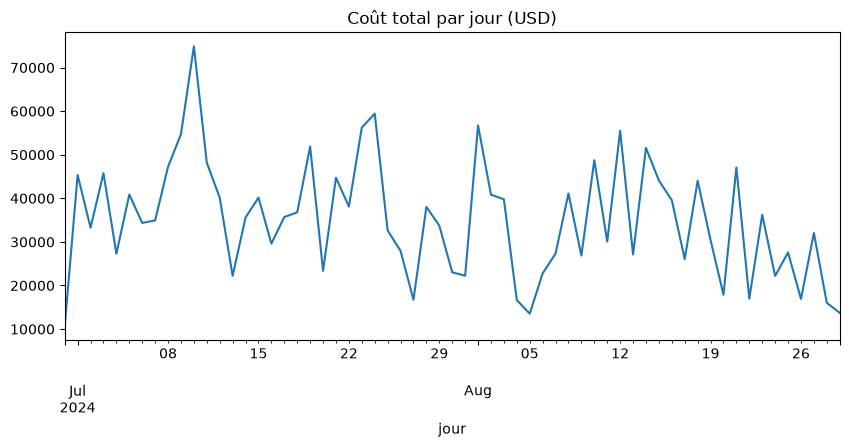

In [2]:
df["jour"] = df["usage_start"].dt.floor("D")  # enlève l'heure, garde la date

cost_by_day = df.groupby("jour")["cost_usd"].sum()
cost_by_day.plot(kind="line", figsize=(10, 4), title="Coût total par jour (USD)")

## 3. Coût par semaine

Jour par jour, c'est trop irrégulier. On regroupe par semaine pour voir la tendance.

<Axes: title={'center': 'Coût total par semaine (USD)'}, xlabel='semaine'>

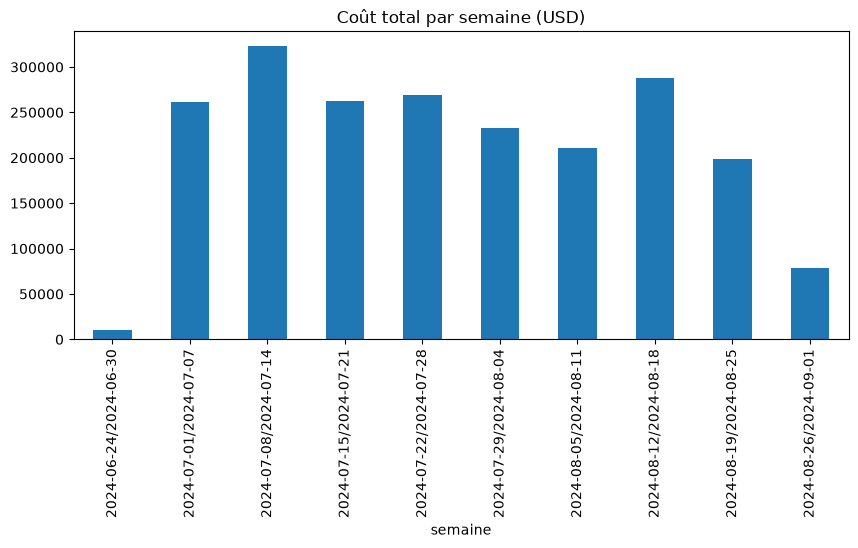

In [3]:
df["semaine"] = df["usage_start"].dt.to_period("W")  # "W" = week ; chaque date -> sa semaine

cost_by_week = df.groupby("semaine")["cost_usd"].sum()
cost_by_week.plot(kind="bar", figsize=(10, 4), title="Coût total par semaine (USD)")

## 4. Coût par jour de la semaine

Est-ce que certains jours reviennent plus chers ?

<Axes: title={'center': 'Coût total par jour de la semaine (USD)'}, xlabel='jour_semaine'>

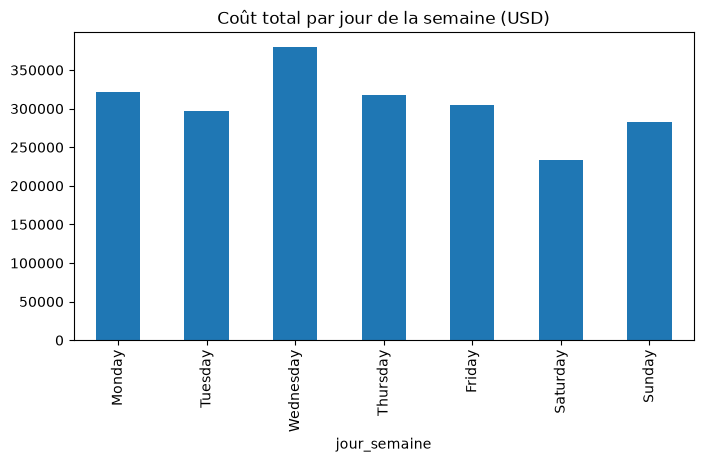

In [4]:
df["jour_semaine"] = df["usage_start"].dt.day_name()

ordre = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

cost_by_weekday = df.groupby("jour_semaine")["cost_usd"].sum()
cost_by_weekday = cost_by_weekday.reindex(ordre)  # force l'ordre lundi -> dimanche (sinon classé A -> Z)

cost_by_weekday.plot(kind="bar", figsize=(8, 4), title="Coût total par jour de la semaine (USD)")

## 5. Les 3 plus gros services dans le temps

À l'étape 3, les services les plus chers sur le total étaient Cloud CDN, Cloud Build et
Pub/Sub. Est-ce qu'ils coûtent cher chaque semaine, ou est-ce qu'un gros pic ponctuel
gonfle leur total ?

<Axes: title={'center': 'Coût par semaine des 3 plus gros services (USD)'}, xlabel='semaine'>

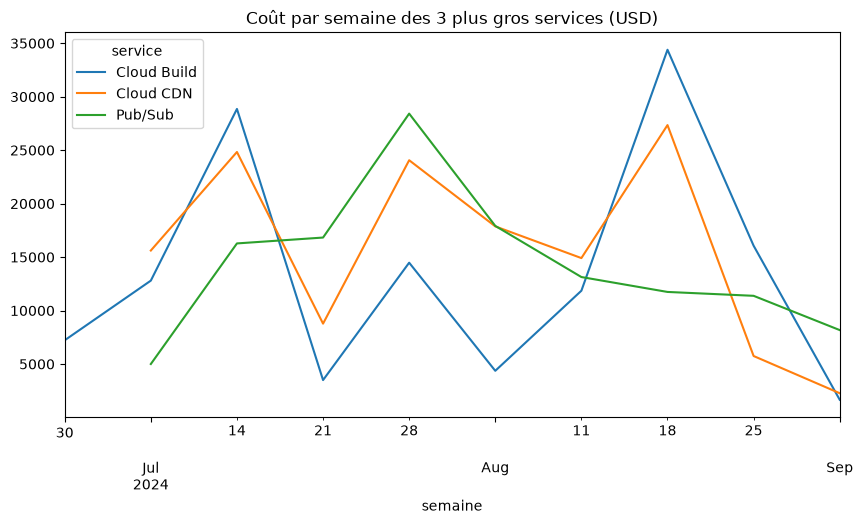

In [5]:
top3 = df.groupby("service")["cost_usd"].sum().sort_values(ascending=False).head(3).index

sub = df[df["service"].isin(top3)]

# unstack : une colonne par service, donc une courbe par service
evolution = sub.groupby(["semaine", "service"])["cost_usd"].sum().unstack()
evolution.plot(figsize=(10, 5), title="Coût par semaine des 3 plus gros services (USD)")

## 6. Coût rapporté à la durée d'usage

`cost_usd` couvre toute la durée où la ressource a tourné. Pour comparer des ressources
qui n'ont pas tourné aussi longtemps, on ramène le coût à une journée.

In [6]:
df["cout_par_jour"] = df["cost_usd"] / df["duree_jours"]

df.sort_values("cout_par_jour", ascending=False)[
    ["resource_id", "service", "region", "cost_usd", "duree_jours", "cout_par_jour"]
].head(10)

,resource_id,service,region,cost_usd,duree_jours,cout_par_jour
168,res-WFOF16UH,Cloud Load Balancing,europe-west3,8260.39,1.009028,8186.484240
173,res-WAAIIIM2,Cloud VPC,asia-east1,8176.42,1.034028,7907.350437
370,res-ORVHD3QJ,Cloud Dataproc,us-east1,8175.95,1.125000,7267.511111
787,res-UOI35WIO,Cloud CDN,europe-west3,7328.55,1.093056,6704.645489
240,res-LWGX075A,Cloud Dataproc,southamerica-east1,8832.79,1.445139,6112.069966
708,res-XCM67VGG,Cloud NAT,asia-east1,5966.29,1.047917,5693.477535
985,res-X1LNU5KK,Cloud Dataproc,us-east1,7284.36,1.377083,5289.701664
408,res-OYTZUKIA,Cloud Data Fusion,us-east1,5986.65,1.179861,5074.029429
654,res-VWM05I69,Cloud Load Balancing,southamerica-east1,7302.74,1.554167,4698.813941
594,res-7LLUZT3G,Cloud Endpoints,europe-north1,7989.93,1.707639,4678.934201


## Synthèse

- Les données vont de fin juin à fin août 2024, soit 10 semaines, mais la première et
  la dernière sont incomplètes
- Pas de tendance : ça tourne autour de 250 000 $ par semaine, ni hausse ni baisse
- La semaine la plus chère, c'est le 8-14 juillet (environ 323 000 $)
- Les jours de la semaine se valent à peu près : mercredi un peu au-dessus, samedi un
  peu en dessous, rien de marqué
- Les 3 gros services sont chers toutes les semaines, ce n'est pas un pic qui fausse le
  classement. Cloud CDN et Pub/Sub restent à peu près au même niveau chaque semaine ;
  Cloud Build varie beaucoup d'une semaine à l'autre (de 3 500 à 34 000 $) 
- La ressource la plus chère à la journée : `res-WFOF16UH` (Cloud Load Balancing,
  europe-west3), 8 260 $ pour un seul jour